**clustering** is an **Unsupervised Machine Learning** technique that groups similar data points into the same cluster based on their characteristics.

Clustering means grouping similar items together.
If we have students with different marks:

High Marks → Group 1,
Average Marks → Group 2,
Low Marks → Group 3.

**Project Title**:
**Country Development Segmentation using K-Means Clustering**

We did this project to identify countries with similar development characteristics.

Instead of analyzing each country individually, clustering automatically groups similar countries together.

This makes analysis easier and helps in better decision-making.

In [68]:
#IMPORT LIBRARIES

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt #graphs and charts
import seaborn as sns #advanced statistical visualization

from sklearn.preprocessing import StandardScaler #to scale all features to the same range

from sklearn.cluster import KMeans #Import KMeans algorithm for clustering

from sklearn.decomposition import PCA # Import PCA for reducing dimensions and visualizing clusters

from sklearn.metrics import silhouette_score #Import Silhouette Score to evaluate clustering quality

import warnings ## Ignore unnecessary warning messages
warnings.filterwarnings('ignore')

In [69]:
# Plot Settings

plt.style.use('ggplot') ## Apply a professional style to all graphs

sns.set(font_scale=1.2) # Increase the font size of graph labels and titles

print("Libraries Imported Successfully")

Libraries Imported Successfully


 above given is optional Your clustering project will work even if you remove these two lines.

In [70]:
import pandas as pd
#it will read the datasets given below
population = pd.read_csv("country_population.csv")
fertility = pd.read_csv("fertility_rate.csv")
life = pd.read_csv("life_expectancy.csv")

In [71]:
population.head()

,Country Name,Country Code,Indicator Name,Indicator Code,1960,1961,1962,1963,1964,1965,...,2007,2008,2009,2010,2011,2012,2013,2014,2015,2016
0,Aruba,ABW,"Population, total",SP.POP.TOTL,54211.0,55438.0,56225.0,56695.0,57032.0,57360.0,...,101220.0,101353.0,101453.0,101669.0,102053.0,102577.0,103187.0,103795.0,104341.0,104822.0
1,Afghanistan,AFG,"Population, total",SP.POP.TOTL,8996351.0,9166764.0,9345868.0,9533954.0,9731361.0,9938414.0,...,26616792.0,27294031.0,28004331.0,28803167.0,29708599.0,30696958.0,31731688.0,32758020.0,33736494.0,34656032.0
2,Angola,AGO,"Population, total",SP.POP.TOTL,5643182.0,5753024.0,5866061.0,5980417.0,6093321.0,6203299.0,...,20997687.0,21759420.0,22549547.0,23369131.0,24218565.0,25096150.0,25998340.0,26920466.0,27859305.0,28813463.0
3,Albania,ALB,"Population, total",SP.POP.TOTL,1608800.0,1659800.0,1711319.0,1762621.0,1814135.0,1864791.0,...,2970017.0,2947314.0,2927519.0,2913021.0,2905195.0,2900401.0,2895092.0,2889104.0,2880703.0,2876101.0
4,Andorra,AND,"Population, total",SP.POP.TOTL,13411.0,14375.0,15370.0,16412.0,17469.0,18549.0,...,82683.0,83861.0,84462.0,84449.0,83751.0,82431.0,80788.0,79223.0,78014.0,77281.0


In [72]:
fertility.head()

,Country Name,Country Code,Indicator Name,Indicator Code,1960,1961,1962,1963,1964,1965,...,2007,2008,2009,2010,2011,2012,2013,2014,2015,2016
0,Aruba,ABW,"Fertility rate, total (births per woman)",SP.DYN.TFRT.IN,4.820,4.655,4.471,4.271,4.059,3.842,...,1.763,1.764,1.769,1.776,1.783,1.791,1.796,1.800,1.801,1.800
1,Afghanistan,AFG,"Fertility rate, total (births per woman)",SP.DYN.TFRT.IN,7.450,7.450,7.450,7.450,7.450,7.450,...,6.460,6.254,6.038,5.816,5.595,5.380,5.174,4.981,4.802,4.635
2,Angola,AGO,"Fertility rate, total (births per woman)",SP.DYN.TFRT.IN,7.478,7.524,7.563,7.592,7.611,7.619,...,6.368,6.307,6.238,6.162,6.082,6.000,5.920,5.841,5.766,5.694
3,Albania,ALB,"Fertility rate, total (births per woman)",SP.DYN.TFRT.IN,6.489,6.401,6.282,6.133,5.960,5.773,...,1.668,1.650,1.646,1.653,1.668,1.685,1.700,1.710,1.714,1.713
4,Andorra,AND,"Fertility rate, total (births per woman)",SP.DYN.TFRT.IN,NaN,NaN,NaN,NaN,NaN,NaN,...,1.180,1.250,1.190,1.270,NaN,NaN,NaN,NaN,NaN,NaN


In [73]:
life.head()

,Country Name,Country Code,Indicator Name,Indicator Code,1960,1961,1962,1963,1964,1965,...,2007,2008,2009,2010,2011,2012,2013,2014,2015,2016
0,Aruba,ABW,"Life expectancy at birth, total (years)",SP.DYN.LE00.IN,65.662,66.074,66.444,66.787,67.113,67.435,...,74.576,74.725,74.872,75.016,75.158,75.299,75.440,75.582,75.725,75.867
1,Afghanistan,AFG,"Life expectancy at birth, total (years)",SP.DYN.LE00.IN,32.292,32.742,33.185,33.624,34.060,34.495,...,59.694,60.243,60.754,61.226,61.666,62.086,62.494,62.895,63.288,63.673
2,Angola,AGO,"Life expectancy at birth, total (years)",SP.DYN.LE00.IN,33.251,33.573,33.914,34.272,34.645,35.031,...,55.096,56.189,57.231,58.192,59.042,59.770,60.373,60.858,61.241,61.547
3,Albania,ALB,"Life expectancy at birth, total (years)",SP.DYN.LE00.IN,62.279,63.298,64.187,64.911,65.461,65.848,...,75.656,75.943,76.281,76.652,77.031,77.389,77.702,77.963,78.174,78.345
4,Andorra,AND,"Life expectancy at birth, total (years)",SP.DYN.LE00.IN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [74]:
print("Population Dataset Shape :",population.shape)
print("Fertility Dataset Shape :",fertility.shape)
print("Life Expectancy Shape :",life.shape)
#it will give shape of all the datasets

Population Dataset Shape : (264, 61)
Fertility Dataset Shape : (264, 61)
Life Expectancy Shape : (264, 61)


**Merge 3 Datasets**

Combine the three datasets into a single dataset.

Why We Use It

A machine learning model requires all related features in one table.

In [75]:
# Select only 'Country Name' and '2016' columns from the population dataset,fertility dataset and life dataset
population = population[['Country Name','2016']]
fertility = fertility[['Country Name','2016']]
life = life[['Country Name','2016']]
# Rename the '2016' column to 'Population' for better understanding
population.rename(columns={'2016':'Population'},inplace=True)
fertility.rename(columns={'2016':'FertilityRate'},inplace=True)
life.rename(columns={'2016':'LifeExpectancy'},inplace=True)

In [76]:
# Merge the population and fertility datasets using the common column 'Country Name'
country = pd.merge(population,
                   fertility,
                   on="Country Name")

In [77]:
# Merge the above dataset with the life expectancy dataset
country = pd.merge(country,
                   life,
                   on="Country Name")

In [78]:
country.head()

,Country Name,Population,FertilityRate,LifeExpectancy
0,Aruba,104822.0,1.800,75.867
1,Afghanistan,34656032.0,4.635,63.673
2,Angola,28813463.0,5.694,61.547
3,Albania,2876101.0,1.713,78.345
4,Andorra,77281.0,NaN,NaN


In [79]:
country.shape

(264, 4)

**Data Cleaning**:
Clean the dataset before applying machine learning.

Why We Use It

Missing values and duplicate records reduce model accuracy.

In [80]:
country.isnull().sum() # Check the number of missing values

,0
Country Name,0
Population,2
FertilityRate,18
LifeExpectancy,19


In [81]:
country.dropna(inplace=True) ## Remove rows containing missing values

In [82]:
country.isnull().sum()

,0
Country Name,0
Population,0
FertilityRate,0
LifeExpectancy,0


In [83]:
country.drop_duplicates(inplace=True) # Remove duplicate rows

In [84]:
country.info()
# Display information about the dataset
# (Number of rows, columns, data types, and missing values)

<class 'pandas.core.frame.DataFrame'>
Index: 244 entries, 0 to 263
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Country Name    244 non-null    object 
 1   Population      244 non-null    float64
 2   FertilityRate   244 non-null    float64
 3   LifeExpectancy  244 non-null    float64
dtypes: float64(3), object(1)
memory usage: 9.5+ KB


In [85]:
country.describe()
# Display statistical summary of numerical columns
# (Count, Mean, Standard Deviation, Minimum, Maximum, etc.)

,Population,FertilityRate,LifeExpectancy
count,2.440000e+02,244.000000,244.000000
mean,3.231802e+08,2.725823,72.020433
std,9.825391e+08,1.291318,7.521853
min,3.194900e+04,1.172000,51.835000
25%,2.874134e+06,1.744250,66.768500
50%,1.137086e+07,2.283500,73.482229
75%,7.133167e+07,3.431500,77.216250
max,7.444027e+09,7.239000,84.226829


In [86]:
# Save the final cleaned dataset as a new CSV file
# index=False prevents the index column from being saved
country.to_csv("Country_Development.csv",index=False)

In [87]:
from google.colab import files

files.download("Country_Development.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [88]:
import pandas as pd
country = pd.read_csv("Country_Development.csv")
country.head()

,Country Name,Population,FertilityRate,LifeExpectancy
0,Aruba,104822.0,1.800000,75.867000
1,Afghanistan,34656032.0,4.635000,63.673000
2,Angola,28813463.0,5.694000,61.547000
3,Albania,2876101.0,1.713000,78.345000
4,Arab World,406452690.0,3.326532,71.198456


In [89]:
print("="*50)  # Print a line of '=' symbols for better output formatting
print("Dataset Shape")
print("="*50)  # Print another separator line

print(country.shape)

print()

print("="*50)  # Print separator line
print("Column Names")
print("="*50)

print(country.columns)

print()

print("="*50)
print("Data Types")
print("="*50)

print(country.dtypes) # Display the data type of each column

Dataset Shape
(244, 4)

Column Names
Index(['Country Name', 'Population', 'FertilityRate', 'LifeExpectancy'], dtype='object')

Data Types
Country Name       object
Population        float64
FertilityRate     float64
LifeExpectancy    float64
dtype: object


In [90]:
country.describe().T # Display statistical summary in row format (Transpose)

,count,mean,std,min,25%,50%,75%,max
Population,244.0,3.231802e+08,9.825391e+08,31949.000,2.874134e+06,1.137086e+07,7.133167e+07,7.444027e+09
FertilityRate,244.0,2.725823e+00,1.291318e+00,1.172,1.744250e+00,2.283500e+00,3.431500e+00,7.239000e+00
LifeExpectancy,244.0,7.202043e+01,7.521853e+00,51.835,6.676850e+01,7.348223e+01,7.721625e+01,8.422683e+01


In [91]:
country.isnull().sum()

,0
Country Name,0
Population,0
FertilityRate,0
LifeExpectancy,0


**Histogram**

A Histogram is a graph that shows the distribution (frequency) of numerical data.

We use a histogram

Check how the data is distributed.
Detect unusual values (outliers).

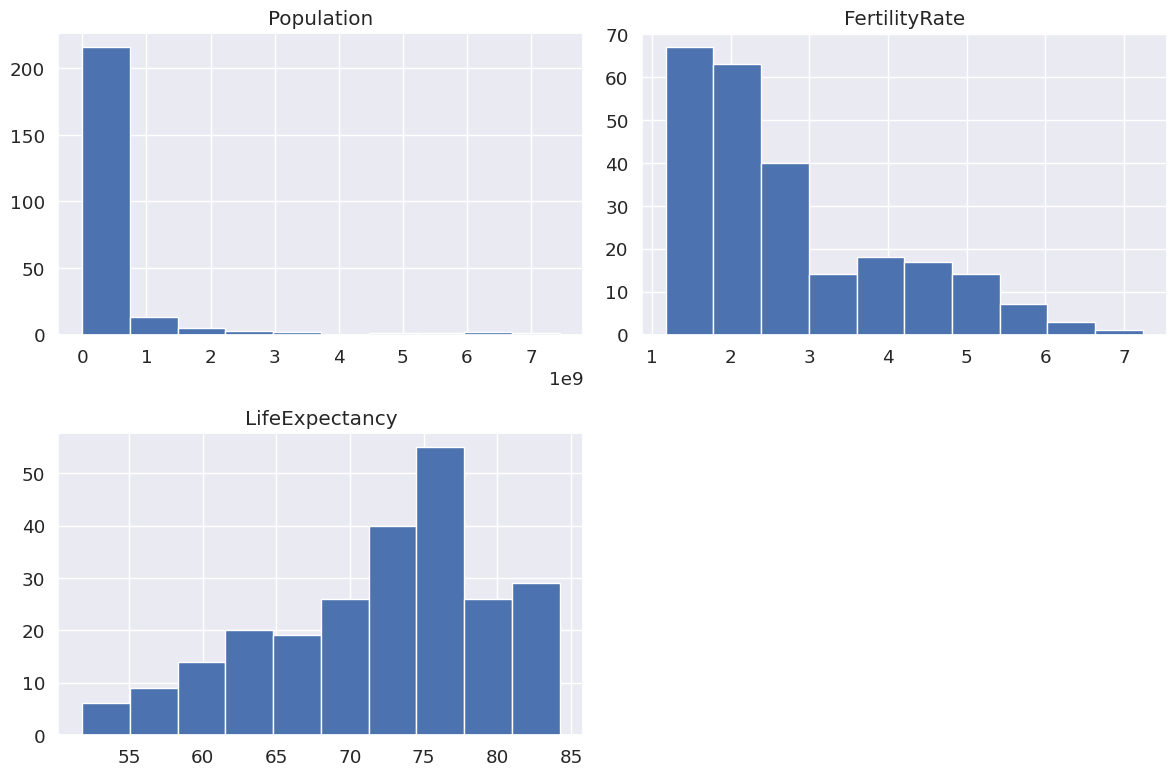

In [92]:
country.hist(figsize=(12,8)) # Plot histograms for all numerical columns in the dataset
plt.tight_layout() # Automatically adjust the spacing between plots
plt.show() # Display all the histograms

histplot() is a Seaborn function used to create a histogram for a single numerical column.

We use it to:

Understand the distribution of a single feature.

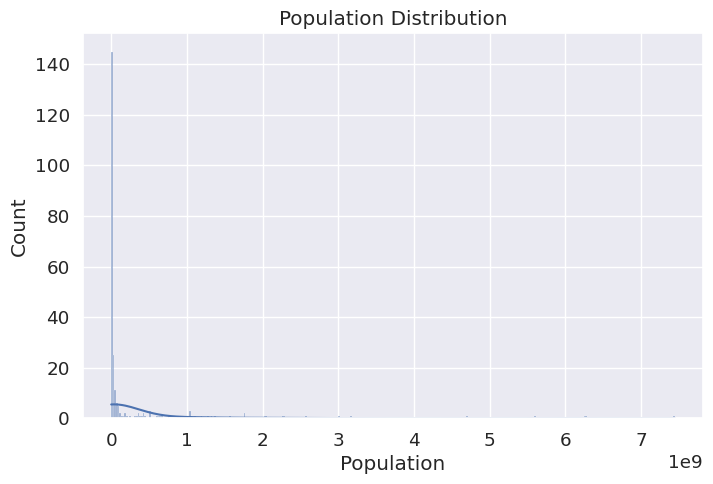

In [93]:
plt.figure(figsize=(8,5))
sns.histplot(country["Population"],kde=True) # Plot the histogram for the Population column
# kde=True adds a smooth density curve to show the data distribution
plt.title("Population Distribution")
plt.show()

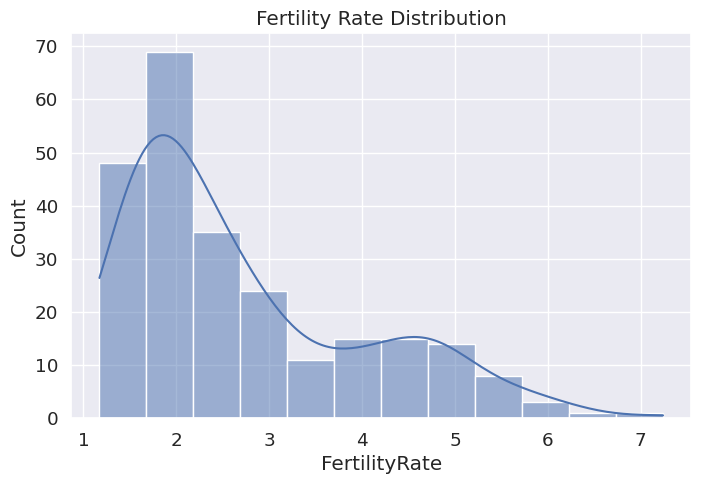

In [94]:
plt.figure(figsize=(8,5))
sns.histplot(country["FertilityRate"],kde=True)
plt.title("Fertility Rate Distribution")
plt.show()

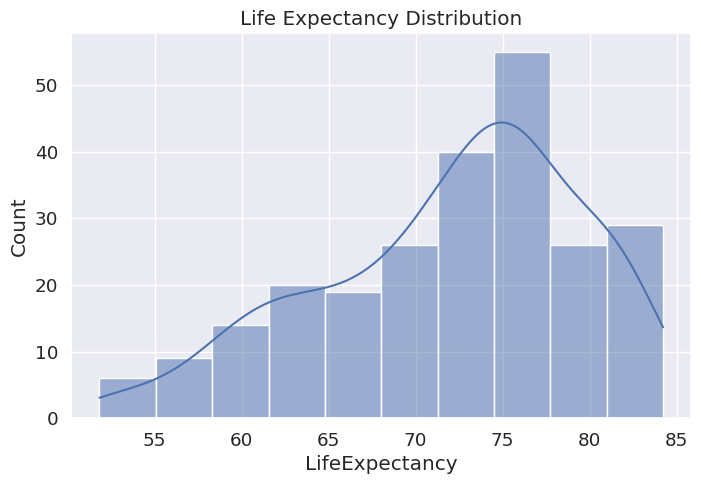

In [95]:
plt.figure(figsize=(8,5))
sns.histplot(country["LifeExpectancy"],kde=True)
plt.title("Life Expectancy Distribution")
plt.show()

A Boxplot is a graph used to show the distribution of data and detect outliers.

We use a boxplot to:

Check whether the data contains outliers.

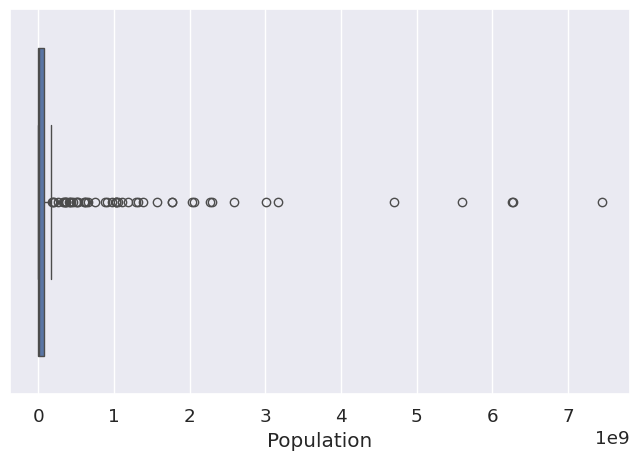

In [96]:
plt.figure(figsize=(8,5))
sns.boxplot(x=country["Population"]) # It helps identify the data distribution and outliers
plt.show()

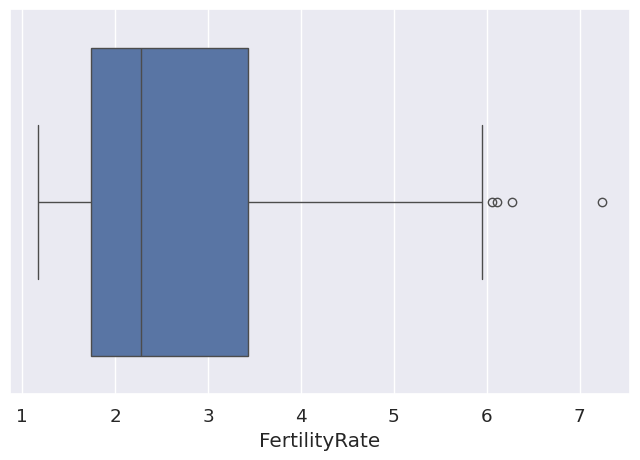

In [97]:
plt.figure(figsize=(8,5))
sns.boxplot(x=country["FertilityRate"]) # It helps identify the data distribution and outliers
plt.show()

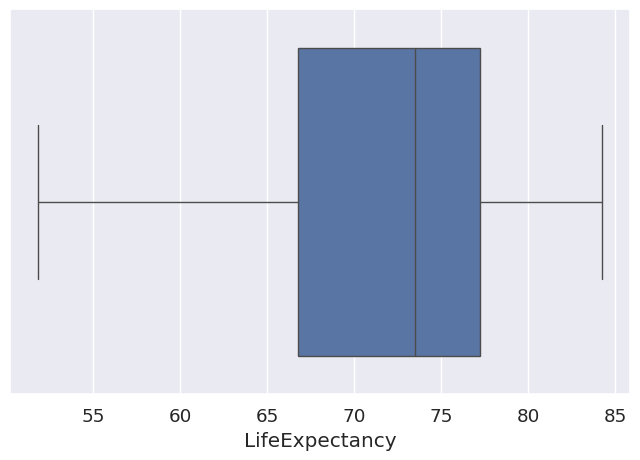

In [98]:
plt.figure(figsize=(8,5))
sns.boxplot(x=country["LifeExpectancy"])
plt.show()

Correlation measures the relationship between two numerical variables.

Population ↑ → Life Expectancy ↑ (Positive Relationship)

Fertility Rate ↑ → Life Expectancy ↓ (Negative Relationship)

We use correlation to:

Understand the relationship between features.

Find positively and negatively related columns.

In [99]:
numeric_data = country.select_dtypes(include=['number']) # Select only numerical columns from the dataset
corr = numeric_data.corr() # Calculate the correlation between all numerical columns
corr # Display the correlation matrix

,Population,FertilityRate,LifeExpectancy
Population,1.000000,-0.040755,-0.034428
FertilityRate,-0.040755,1.000000,-0.851152
LifeExpectancy,-0.034428,-0.851152,1.000000


A Heatmap is a graphical representation of data using different colors.

It shows the correlation between numerical columns using colors.

🔴 Red → Strong Positive Correlation

🔵 Blue → Strong Negative Correlation

⚪ Light Color → Weak or No Correlation

We use a heatmap to:

Easily understand the relationship between features.

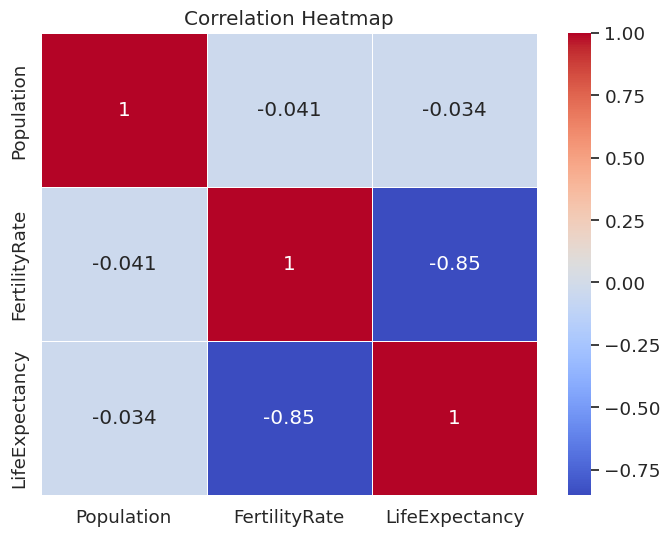

In [100]:
plt.figure(figsize=(8,6))

sns.heatmap(corr, # Create a heatmap using the correlation matrix
            annot=True,  # Display the correlation values inside each box
            cmap="coolwarm",  # Apply the 'coolwarm' color theme
            linewidths=0.5) # Add small lines between cells for better visibility


plt.title("Correlation Heatmap")

plt.show()

A Pair Plot is a graph that shows the relationship between every numerical feature in the dataset.

We use a pair plot to:

Understand the relationship between numerical features.

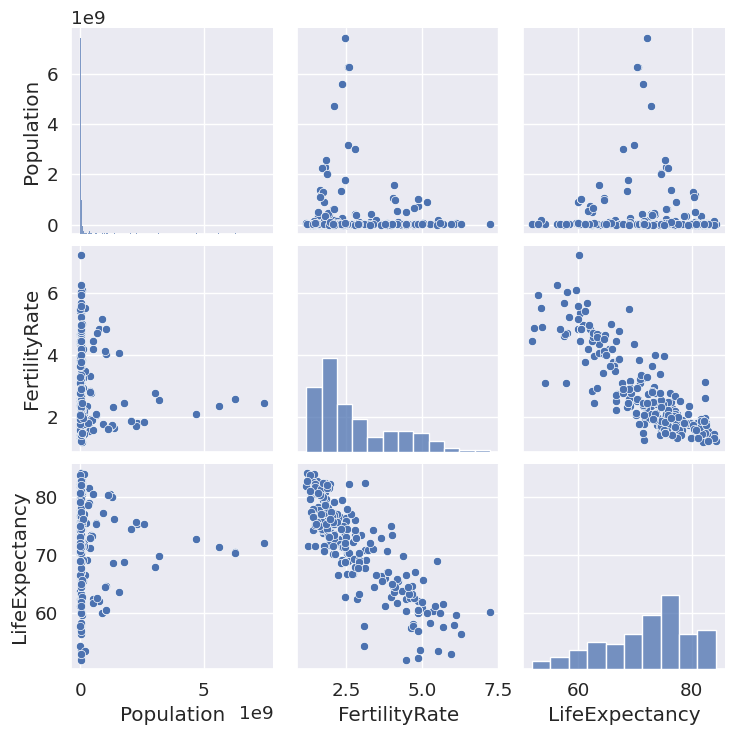

In [101]:
# Create pair plots for all numerical columns
# It shows the relationship between every pair of numerical features
sns.pairplot(numeric_data)
plt.show()

A Bar Plot is a graph used to compare values between different categories using bars.

We use a bar plot to:

Compare values between countries.

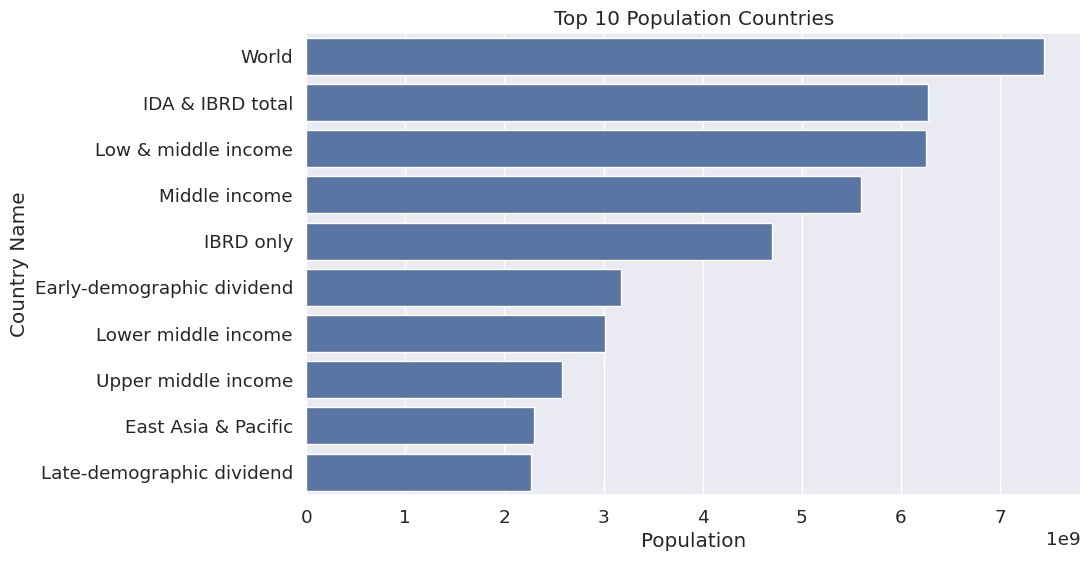

In [102]:
# Sort the dataset by Population in descending order
# and select the top 10 countries
top10 = country.sort_values("Population",ascending=False).head(10)

plt.figure(figsize=(10,6))
# Create a horizontal bar plot
# X-axis shows Population
# Y-axis shows Country Name
sns.barplot(data=top10,
            x="Population",
            y="Country Name")

plt.title("Top 10 Population Countries")

plt.show()

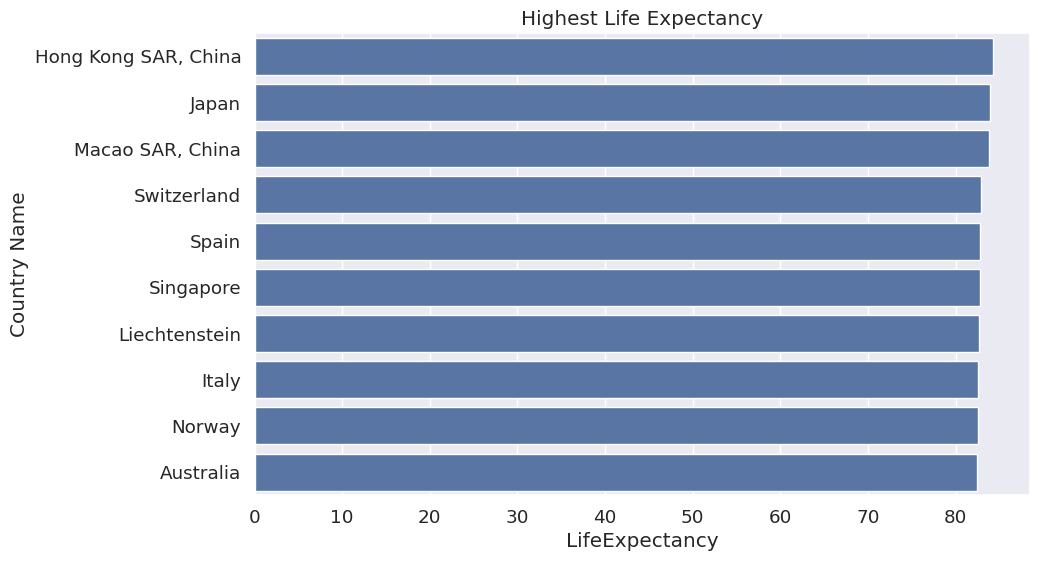

In [103]:
top10 = country.sort_values("LifeExpectancy",ascending=False).head(10)

plt.figure(figsize=(10,6))

sns.barplot(data=top10,
            x="LifeExpectancy",
            y="Country Name")

plt.title("Highest Life Expectancy")

plt.show()

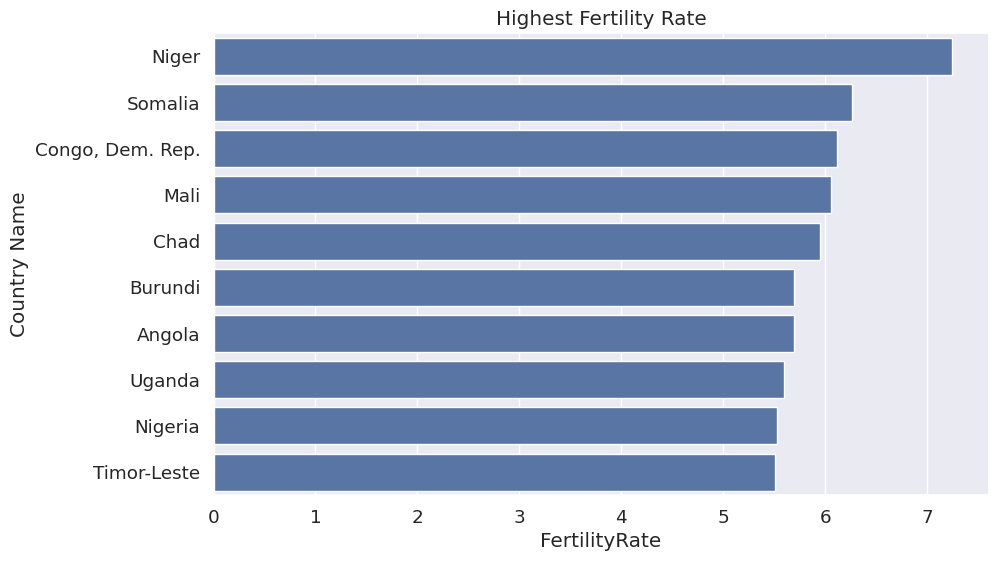

In [104]:
top10 = country.sort_values("FertilityRate",ascending=False).head(10)

plt.figure(figsize=(10,6))

sns.barplot(data=top10,
            x="FertilityRate",
            y="Country Name")

plt.title("Highest Fertility Rate")

plt.show()

A Scatter Plot is a graph that shows the relationship between two numerical variables using dots.

We use a scatter plot to:

Understand the relationship between two numerical features.

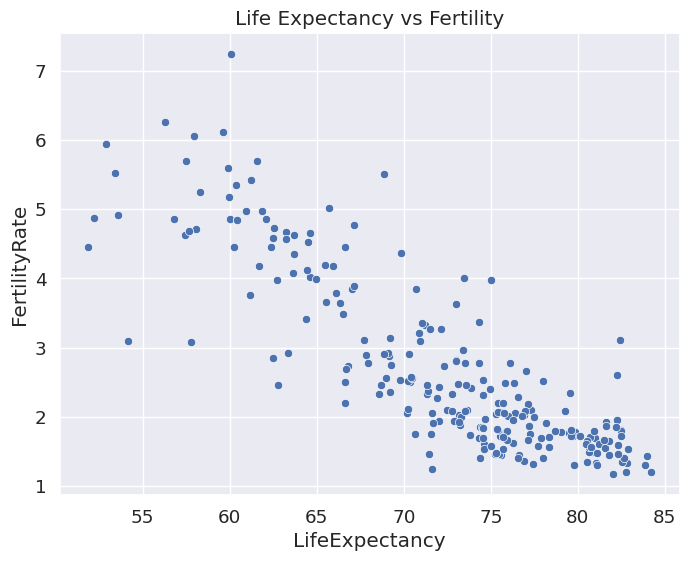

In [105]:
plt.figure(figsize=(8,6))
# Create a scatter plot
# Each dot represents one country
sns.scatterplot(data=country,
                x="LifeExpectancy",
                y="FertilityRate")

plt.title("Life Expectancy vs Fertility")

plt.show()

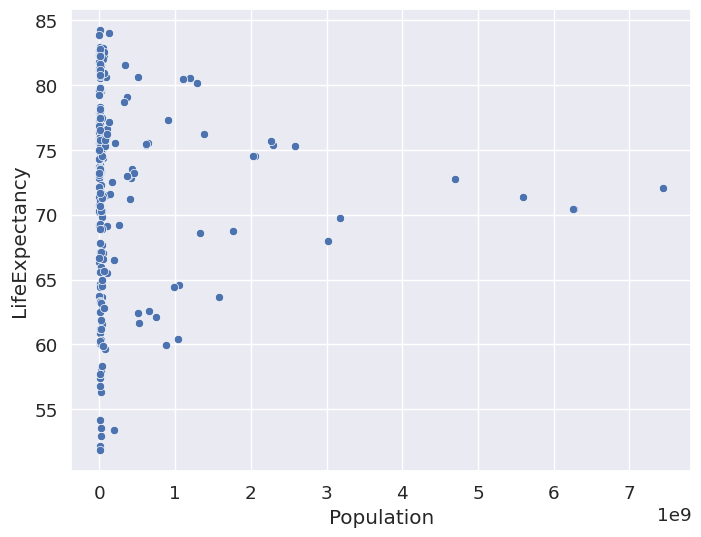

In [106]:
plt.figure(figsize=(8,6))

sns.scatterplot(data=country,
                x="Population",
                y="LifeExpectancy")

plt.show()

**Feature Engineering** is the process of selecting, creating, or preparing useful features (columns) for a Machine Learning model.

We use Feature Engineering to:

Select important features.
Remove unnecessary columns.

In [107]:
data = country.copy() # Create a copy of the dataset
data.head()

,Country Name,Population,FertilityRate,LifeExpectancy
0,Aruba,104822.0,1.800000,75.867000
1,Afghanistan,34656032.0,4.635000,63.673000
2,Angola,28813463.0,5.694000,61.547000
3,Albania,2876101.0,1.713000,78.345000
4,Arab World,406452690.0,3.326532,71.198456


In [108]:
country_names = data["Country Name"] # Store the Country Name column separately

In [109]:
# Select only the numerical features for clustering
X = data[[
    "Population",
    "FertilityRate",
    "LifeExpectancy"
]]

X.head()

,Population,FertilityRate,LifeExpectancy
0,104822.0,1.800000,75.867000
1,34656032.0,4.635000,63.673000
2,28813463.0,5.694000,61.547000
3,2876101.0,1.713000,78.345000
4,406452690.0,3.326532,71.198456


In [110]:
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 244 entries, 0 to 243
Data columns (total 3 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Population      244 non-null    float64
 1   FertilityRate   244 non-null    float64
 2   LifeExpectancy  244 non-null    float64
dtypes: float64(3)
memory usage: 5.8 KB


In [111]:
X.skew() # Calculate the skewness of each feature

,0
Population,4.806527
FertilityRate,1.052802
LifeExpectancy,-0.598013


In [112]:
import numpy as np
X["Population"] = np.log1p(X["Population"])
# Apply log transformation to the Population column

In [113]:
X.head()

,Population,FertilityRate,LifeExpectancy
0,11.560028,1.800000,75.867000
1,17.360982,4.635000,63.673000
2,17.176353,5.694000,61.547000
3,14.871946,1.713000,78.345000
4,19.822978,3.326532,71.198456


In [114]:
X.describe().T

,count,mean,std,min,25%,50%,75%,max
Population,244.0,16.513463,2.754643,10.371927,14.871261,16.246561,18.081131,22.730678
FertilityRate,244.0,2.725823,1.291318,1.172000,1.744250,2.283500,3.431500,7.239000
LifeExpectancy,244.0,72.020433,7.521853,51.835000,66.768500,73.482229,77.216250,84.226829


In [115]:
X.to_csv("Features.csv", index=False)  # Save the selected features into a CSV file

**Data Scaling** Data Scaling is the process of converting all features to the same scale.

We use Data Scaling to:

Make all features have equal importance.

In [116]:
from sklearn.preprocessing import StandardScaler

In [117]:
scaler = StandardScaler() # Create a StandardScaler object
X_scaled = scaler.fit_transform(X) # Scale the features

In [118]:
X_scaled = pd.DataFrame(  # Convert scaled data into DataFrame
    X_scaled,
    columns=X.columns
)

X_scaled.head()

,Population,FertilityRate,LifeExpectancy
0,-1.801909,-0.718434,0.512437
1,0.308302,1.481510,-1.112039
2,0.241139,2.303288,-1.395263
3,-0.597134,-0.785945,0.842554
4,1.203901,0.466147,-0.109503


In [119]:
print(X_scaled.mean()) # Print mean of each feature
print()
print(X_scaled.std())  # Print standard deviation

Population        4.004083e-17
FertilityRate    -6.552136e-17
LifeExpectancy    6.260930e-16
dtype: float64

Population        1.002056
FertilityRate     1.002056
LifeExpectancy    1.002056
dtype: float64


In [120]:
X_scaled.to_csv("Scaled_Data.csv",index=False) # Save scaled data into CSV

**Elbow Method** The Elbow Method helps us find the best number of clusters.

In [121]:
from sklearn.cluster import KMeans

**WCSS = Within Cluster Sum of Squares**

In [122]:
wcss = [] # Empty list to store WCSS values

In [123]:
for i in range(1,11): # Try clusters from 1 to 10
    # Create KMeans model
    model = KMeans(
        n_clusters=i,
        random_state=42,
        n_init=10
    )

    model.fit(X_scaled)

    wcss.append(model.inertia_)

**Plot Elbow Graph**

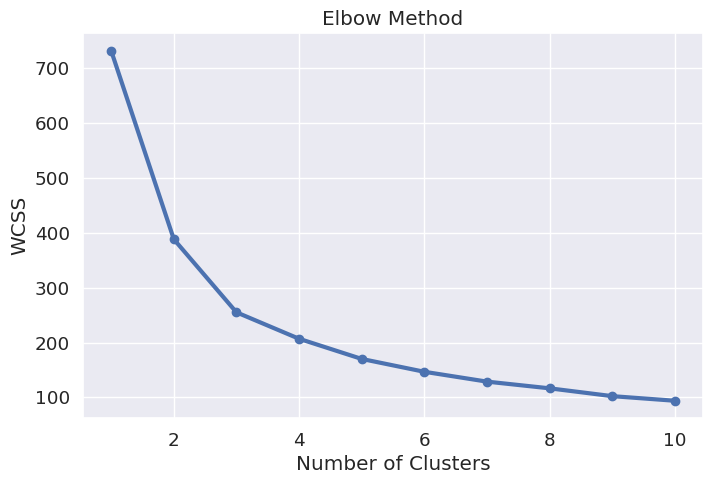

In [124]:
plt.figure(figsize=(8,5))
# Plot WCSS values
plt.plot(range(1,11),wcss,
         marker='o',
         linewidth=3)

plt.xlabel("Number of Clusters")

plt.ylabel("WCSS")

plt.title("Elbow Method")

plt.grid(True)

plt.show()

In [125]:
k = 3

In [126]:
k = 4

**Silhouette Score**

It measures how well the data points are grouped into clusters.

why we use it

To find which K value gives the best clustering.

In [127]:
from sklearn.metrics import silhouette_score

for i in range(2,11):

    model = KMeans(
        n_clusters=i,
        random_state=42,
        n_init=10
    )
    # Predict clusters
    labels = model.fit_predict(X_scaled)

    score = silhouette_score(X_scaled,labels)

    print("Clusters:",i," Score:",round(score,3))

Clusters: 2  Score: 0.456
Clusters: 3  Score: 0.381
Clusters: 4  Score: 0.347
Clusters: 5  Score: 0.343
Clusters: 6  Score: 0.331
Clusters: 7  Score: 0.323
Clusters: 8  Score: 0.328
Clusters: 9  Score: 0.328
Clusters: 10  Score: 0.313


In [128]:
k = 3

In [129]:
kmeans = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

In [130]:
clusters = kmeans.fit_predict(X_scaled)  # Predict cluster labels

In [131]:
country["Cluster"] = clusters # Add cluster labels to the dataset

In [132]:
country.head()

,Country Name,Population,FertilityRate,LifeExpectancy,Cluster
0,Aruba,104822.0,1.800000,75.867000,1
1,Afghanistan,34656032.0,4.635000,63.673000,0
2,Angola,28813463.0,5.694000,61.547000,0
3,Albania,2876101.0,1.713000,78.345000,1
4,Arab World,406452690.0,3.326532,71.198456,2


In [133]:
country["Cluster"].value_counts() # Count countries in each cluster

,count
Cluster,
1,113
2,68
0,63


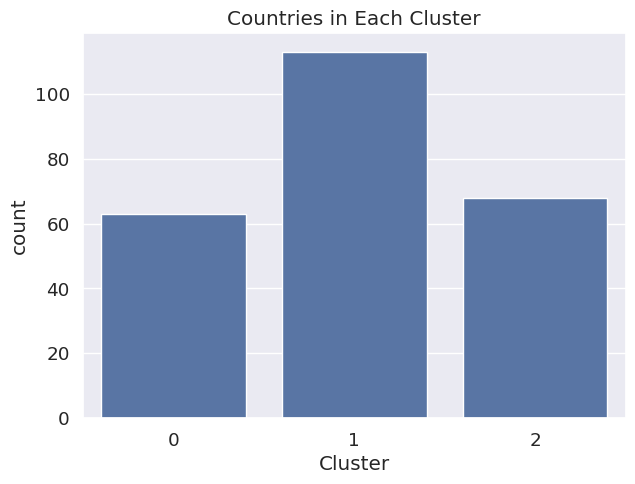

In [134]:
plt.figure(figsize=(7,5))
# Plot cluster counts
sns.countplot(
    x="Cluster",
    data=country
)

plt.title("Countries in Each Cluster")

plt.show()

In [135]:
country.groupby("Cluster").mean(numeric_only=True)  # Calculate average values for each cluster

,Population,FertilityRate,LifeExpectancy
Cluster,,,
0,1.807037e+08,4.579505,61.601269
1,5.140120e+06,2.088613,76.056491
2,9.836881e+08,2.067336,74.966503


In [136]:
# Save clustered dataset
country.to_csv(
    "Country_Clusters.csv",
    index=False
)

**PCA Visualization** PCA (Principal Component Analysis) is a dimensionality reduction technique.

It converts multiple features into fewer features while keeping most of the important information.

In your project:

Original Features = 3
(Population,
Fertility Rate,
Life Expectancy,)

After PCA

PCA1

PCA2

These two components are used only for visualization.

In [137]:
from sklearn.decomposition import PCA

In [138]:
pca = PCA(n_components=2) # Create PCA model with 2 components

X_pca = pca.fit_transform(X_scaled) # Transform scaled data into 2 principal components

In [139]:
country["PCA1"] = X_pca[:,0]  # Store first and 2nd principal component

country["PCA2"] = X_pca[:,1]

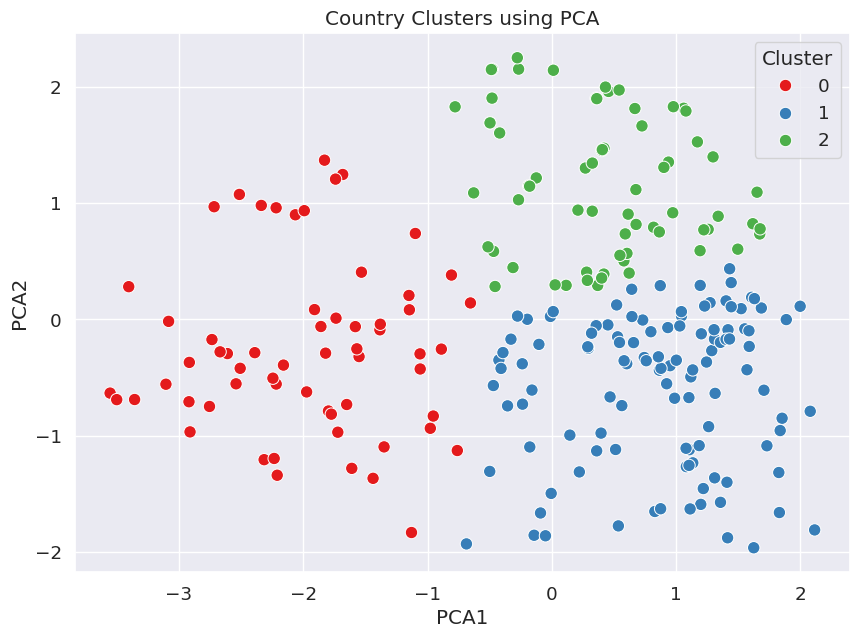

In [140]:
plt.figure(figsize=(10,7))

sns.scatterplot(
    x="PCA1",
    y="PCA2",
    hue="Cluster",
    palette="Set1",
    data=country,
    s=80
)

plt.title("Country Clusters using PCA")

plt.show()

Shows all countries in a 2D graph.

Why?

To clearly see the clusters.

Different colors represent different clusters.

In [141]:
centers = pca.transform(kmeans.cluster_centers_) #Converts cluster centers into PCA coordinates.

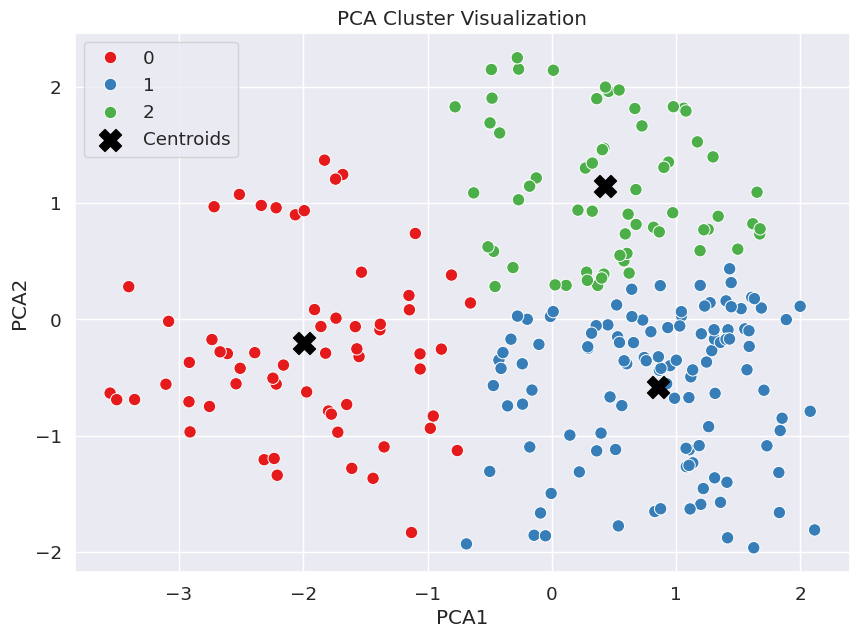

In [142]:
plt.figure(figsize=(10,7))

sns.scatterplot(
    x="PCA1",
    y="PCA2",
    hue="Cluster",
    data=country,
    palette="Set1",
    s=80
)

plt.scatter(
    centers[:,0],
    centers[:,1],
    c='black',
    s=250,
    marker='X',
    label='Centroids'
)

plt.legend()

plt.title("PCA Cluster Visualization")

plt.show()

Draws cluster centers.

Why?

To show the center of each cluster.

Black X = Cluster Center

In [143]:
print("Explained Variance")

print(pca.explained_variance_ratio_)

Explained Variance
[0.62825023 0.32274287]


62.83%
+
32.27%
------------
95.10%

So PCA preserved about 95.1% of your original dataset information.

Why doesn't it become exactly 100%?

Because you reduced:

3 original features
(Population,
Fertility Rate,
Life Expectancy)

↓

to only

PCA1

PCA2

A small amount of information (about 4.9%) is lost during dimensionality reduction, which is completely normal.

In [144]:
country.to_csv(
    "Final_Country_Clusters.csv",
    index=False
)

Saves the final dataset with cluster labels and PCA values.

Why?

To use the final clustered dataset later for analysis or reporting.

**Cluster Interpretation** Cluster Interpretation is the process of understanding the characteristics of each cluster.

In [145]:
# Calculate the average values of each cluster
cluster_summary = country.groupby("Cluster").agg({
    "Population":"mean",
    "FertilityRate":"mean",
    "LifeExpectancy":"mean"
})

cluster_summary

,Population,FertilityRate,LifeExpectancy
Cluster,,,
0,1.807037e+08,4.579505,61.601269
1,5.140120e+06,2.088613,76.056491
2,9.836881e+08,2.067336,74.966503


In [146]:
cluster_summary.round(2) # Round the values to 2 decimal places

,Population,FertilityRate,LifeExpectancy
Cluster,,,
0,1.807037e+08,4.58,61.60
1,5.140120e+06,2.09,76.06
2,9.836881e+08,2.07,74.97


In [147]:
country["Cluster"].value_counts() # Count the number of countries in each cluster

,count
Cluster,
1,113
2,68
0,63


In [148]:
# Loop through each cluster
for i in sorted(country["Cluster"].unique()):
    # Print a separator line
    print("="*60)
    # Print cluster number
    print("Cluster",i)

    print("="*60)
    # Print the list of country names in the cluster
    print(country[country["Cluster"]==i]["Country Name"].tolist())

    print()

Cluster 0
['Afghanistan', 'Angola', 'Burundi', 'Benin', 'Burkina Faso', 'Central African Republic', "Cote d'Ivoire", 'Cameroon', 'Congo, Dem. Rep.', 'Congo, Rep.', 'Comoros', 'Djibouti', 'Ethiopia', 'Fragile and conflict affected situations', 'Gabon', 'Ghana', 'Guinea', 'Gambia, The', 'Guinea-Bissau', 'Equatorial Guinea', 'Heavily indebted poor countries (HIPC)', 'Haiti', 'IDA total', 'IDA blend', 'IDA only', 'Iraq', 'Kenya', 'Liberia', 'Least developed countries: UN classification', 'Low income', 'Lesotho', 'Madagascar', 'Mali', 'Mozambique', 'Mauritania', 'Malawi', 'Namibia', 'Niger', 'Nigeria', 'Other small states', 'Pakistan', 'Papua New Guinea', 'Pre-demographic dividend', 'Rwanda', 'Sudan', 'Senegal', 'Sierra Leone', 'Somalia', 'Sub-Saharan Africa (excluding high income)', 'South Sudan', 'Sub-Saharan Africa', 'Sao Tome and Principe', 'Swaziland', 'Chad', 'Togo', 'Timor-Leste', 'Sub-Saharan Africa (IDA & IBRD countries)', 'Tanzania', 'Uganda', 'Yemen, Rep.', 'South Africa', 'Zambi

In [149]:
cluster_summary.to_csv("Cluster_Summary.csv")

Example Interpretation

Cluster 0

High Life Expectancy
Low Fertility
Stable Population

➡ Developed Countries

Cluster 1

Medium Population
Medium Fertility
Medium Life Expectancy

➡ Developing Countries

Cluster 2

High Fertility
Low Life Expectancy

➡ Underdeveloped Countries

**Inference**  means using a trained machine learning model to make predictions on new/unseen data.

We use inference to:

Understand the clustering results.
Explain what each cluster represents.

In [150]:
# Group the dataset by Cluster
# and calculate the average values
cluster_summary = country.groupby("Cluster").agg({
    "Population": "mean",
    "FertilityRate": "mean",
    "LifeExpectancy": "mean"
})

# Display the cluster summary
cluster_summary

,Population,FertilityRate,LifeExpectancy
Cluster,,,
0,1.807037e+08,4.579505,61.601269
1,5.140120e+06,2.088613,76.056491
2,9.836881e+08,2.067336,74.966503


In [151]:
# Round all values to 2 decimal places
cluster_summary.round(2)

,Population,FertilityRate,LifeExpectancy
Cluster,,,
0,1.807037e+08,4.58,61.60
1,5.140120e+06,2.09,76.06
2,9.836881e+08,2.07,74.97


In [152]:
# Count the number of countries in each cluster
country["Cluster"].value_counts()

,count
Cluster,
1,113
2,68
0,63


In [153]:
# Loop through every cluster
for i in sorted(country["Cluster"].unique()):

    # Print a separator line
    print("="*60)

    # Print cluster number
    print("Cluster", i)

    # Print another separator line
    print("="*60)

    # Print all country names in the cluster
    print(country[country["Cluster"] == i]["Country Name"].tolist())

    # Print a blank line
    print()

Cluster 0
['Afghanistan', 'Angola', 'Burundi', 'Benin', 'Burkina Faso', 'Central African Republic', "Cote d'Ivoire", 'Cameroon', 'Congo, Dem. Rep.', 'Congo, Rep.', 'Comoros', 'Djibouti', 'Ethiopia', 'Fragile and conflict affected situations', 'Gabon', 'Ghana', 'Guinea', 'Gambia, The', 'Guinea-Bissau', 'Equatorial Guinea', 'Heavily indebted poor countries (HIPC)', 'Haiti', 'IDA total', 'IDA blend', 'IDA only', 'Iraq', 'Kenya', 'Liberia', 'Least developed countries: UN classification', 'Low income', 'Lesotho', 'Madagascar', 'Mali', 'Mozambique', 'Mauritania', 'Malawi', 'Namibia', 'Niger', 'Nigeria', 'Other small states', 'Pakistan', 'Papua New Guinea', 'Pre-demographic dividend', 'Rwanda', 'Sudan', 'Senegal', 'Sierra Leone', 'Somalia', 'Sub-Saharan Africa (excluding high income)', 'South Sudan', 'Sub-Saharan Africa', 'Sao Tome and Principe', 'Swaziland', 'Chad', 'Togo', 'Timor-Leste', 'Sub-Saharan Africa (IDA & IBRD countries)', 'Tanzania', 'Uganda', 'Yemen, Rep.', 'South Africa', 'Zambi